In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

## Load your dataset

In [34]:
df = pd.read_csv("diabetes_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 16)


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


## Separate features and target

In [35]:
target_column = "diabetes"

In [36]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (100000, 15)
Target: (100000,)


## Identify categorical and numerical features

In [37]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'location', 'smoking_history']

Numerical features:
['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level']


## Train-test split

## we will use 80-20 split


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 15)
Testing data: (20000, 15)


In [39]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Testing distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


## Create the preprocessing pipeline

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

## SIX Models

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

## Create the model pipelines

In [42]:
from sklearn.pipeline import Pipeline

pipelines = {}

for model_name, model in models.items():

    pipelines[model_name] = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("classifier", model)
        ]
    )

In [43]:
nb_pipeline = pipelines["Naive Bayes"]

nb_pipeline.fit(X_train, y_train)

print("Naive Bayes training successful!")

Naive Bayes training successful!


## Train and evaluate the models

In [44]:
import time

results = []
trained_models = {}

for model_name, pipeline in pipelines.items():

    print("=" * 60)
    print(f"Training: {model_name}")

    start_time = time.time()

    pipeline.fit(X_train, y_train)

    training_time = time.time() - start_time

    print(
        f"{model_name} training completed "
        f"in {training_time:.2f} seconds"
    )

    y_pred = pipeline.predict(X_test)

    # Get probability scores for AUC
    if hasattr(pipeline, "predict_proba"):
        y_probability = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_probability = pipeline.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results.append({
        "ML Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc,
        "Training Time (sec)": training_time
    })

    trained_models[model_name] = pipeline

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"AUC       : {auc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"MCC       : {mcc:.4f}")

Training: Logistic Regression
Logistic Regression training completed in 0.13 seconds
Accuracy  : 0.9610
AUC       : 0.9617
Precision : 0.8692
Recall    : 0.6371
F1 Score  : 0.7352
MCC       : 0.7248
Training: Decision Tree


/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/s

Decision Tree training completed in 0.22 seconds
Accuracy  : 0.9714
AUC       : 0.9717
Precision : 0.9585
Recall    : 0.6929
F1 Score  : 0.8044
MCC       : 0.8015
Training: KNN
KNN training completed in 0.03 seconds
Accuracy  : 0.9578
AUC       : 0.9045
Precision : 0.9289
Recall    : 0.5453
F1 Score  : 0.6872
MCC       : 0.6934
Training: Naive Bayes
Naive Bayes training completed in 0.09 seconds
Accuracy  : 0.6145
AUC       : 0.8901
Precision : 0.1736
Recall    : 0.9400
F1 Score  : 0.2930
MCC       : 0.2933
Training: Random Forest
Random Forest training completed in 0.90 seconds
Accuracy  : 0.9233
AUC       : 0.9724
Precision : 0.5295
Recall    : 0.8718
F1 Score  : 0.6588
MCC       : 0.6429
Training: SVM
SVM training completed in 469.40 seconds
Accuracy  : 0.9634
AUC       : 0.8866
Precision : 0.9672
Recall    : 0.5894
F1 Score  : 0.7325
MCC       : 0.7394


## comparison table

In [45]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC,Training Time (sec)
0,Decision Tree,0.97135,0.971683,0.958503,0.692941,0.804370,0.801450,0.221496
1,Logistic Regression,0.96100,0.961688,0.869181,0.637059,0.735234,0.724784,0.133624
2,SVM,0.96340,0.886649,0.967181,0.589412,0.732456,0.739355,469.395939
3,KNN,0.95780,0.904534,0.928858,0.545294,0.687176,0.693449,0.032776
4,Random Forest,0.92325,0.972392,0.529475,0.871765,0.658813,0.642912,0.898385
5,Naive Bayes,0.61450,0.890083,0.173582,0.940000,0.293050,0.293340,0.088232


In [46]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_display = results_df.copy()

results_display[metric_columns] = results_display[
    metric_columns
].round(4)

results_display

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC,Training Time (sec)
0,Decision Tree,0.9714,0.9717,0.9585,0.6929,0.8044,0.8015,0.221496
1,Logistic Regression,0.9610,0.9617,0.8692,0.6371,0.7352,0.7248,0.133624
2,SVM,0.9634,0.8866,0.9672,0.5894,0.7325,0.7394,469.395939
3,KNN,0.9578,0.9045,0.9289,0.5453,0.6872,0.6934,0.032776
4,Random Forest,0.9232,0.9724,0.5295,0.8718,0.6588,0.6429,0.898385
5,Naive Bayes,0.6145,0.8901,0.1736,0.9400,0.2930,0.2933,0.088232


In [47]:
results_display.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


## Save Trained Models

In [48]:
import os

os.makedirs("model", exist_ok=True)

In [49]:
for model_name, trained_pipeline in trained_models.items():

    file_name = (
        model_name
        .lower()
        .replace(" ", "_")
        + ".pkl"
    )

    file_path = os.path.join(
        "model",
        file_name
    )

    joblib.dump(
        trained_pipeline,
        file_path
    )

    print(f"Saved: {file_path}")

Saved: model/logistic_regression.pkl
Saved: model/decision_tree.pkl
Saved: model/knn.pkl
Saved: model/naive_bayes.pkl
Saved: model/random_forest.pkl
Saved: model/svm.pkl


## Confusion Matrix for all models 

/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


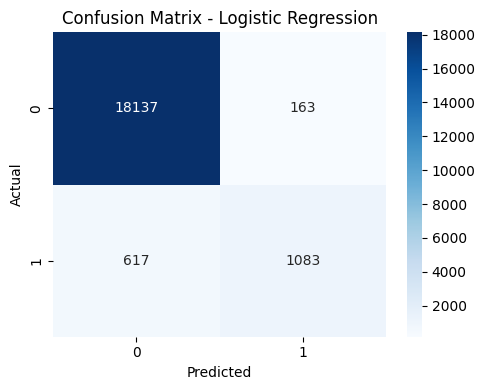

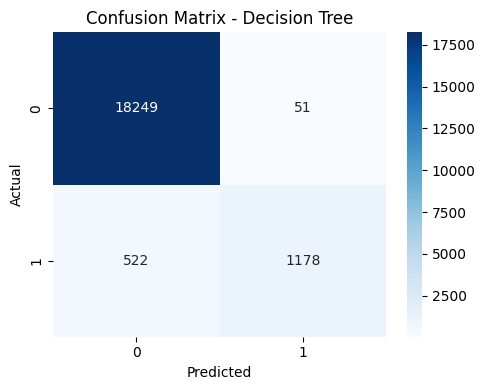

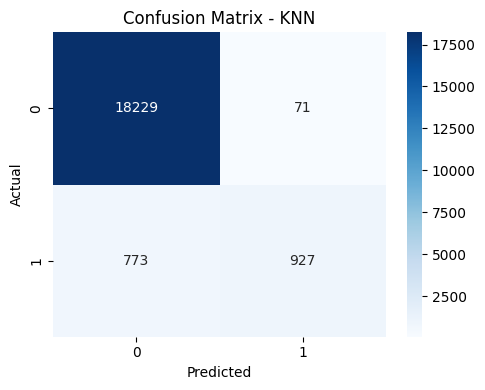

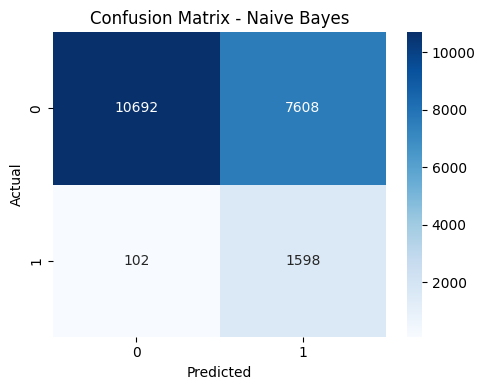

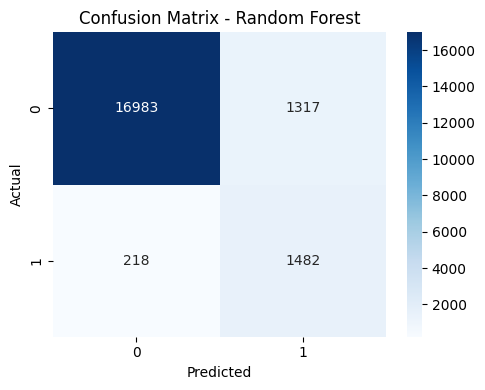

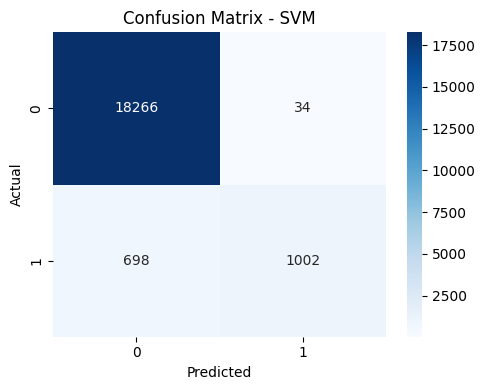

In [50]:
for model_name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

## Classification Report 

In [51]:
for model_name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Non-Diabetic",
                "Diabetic"
            ],
            zero_division=0
        )
    )

/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chiragarora/Desktop/2025AC05139_ML_Assignment2/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Logistic Regression
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.99      0.98     18300
    Diabetic       0.87      0.64      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000


Decision Tree
              precision    recall  f1-score   support

Non-Diabetic       0.97      1.00      0.98     18300
    Diabetic       0.96      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000


KNN
              precision    recall  f1-score   support

Non-Diabetic       0.96      1.00      0.98     18300
    Diabetic       0.93      0.55      0.69      1700

    accuracy                           0.96     20000
   macro avg       0.94      0.77      0.83     20000
weighted avg       0.96      0.96

## Best Model 

In [52]:
winner = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Overall Winner:")
print(winner)

Overall Winner:
ML Model               Decision Tree
Accuracy                     0.97135
AUC                         0.971683
Precision                   0.958503
Recall                      0.692941
F1 Score                     0.80437
MCC                          0.80145
Training Time (sec)         0.221496
Name: 0, dtype: object


In [53]:
winner = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Overall Winner:")
print(winner)

Overall Winner:
ML Model               Decision Tree
Accuracy                     0.97135
AUC                         0.971683
Precision                   0.958503
Recall                      0.692941
F1 Score                     0.80437
MCC                          0.80145
Training Time (sec)         0.221496
Name: 0, dtype: object


In [54]:
test_data = X_test.copy()

test_data["diabetes"] = y_test.values

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("Test data saved:", test_data.shape)

Test data saved: (20000, 16)
